# Isolation Forest - Anomaly Detection

### Create Dummy Dataset with Anomalies

In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import make_blobs

# -------------------------
# Normal data: 2 clusters
# -------------------------
X_normal, _ = make_blobs(
    n_samples=400,
    centers=[
        [-2, 5],   # Cluster 1
        [2, 1]     # Cluster 2
    ],
    cluster_std=0.6,
    random_state=42
)

# -------------------------
# Anomalies / outliers
# -------------------------
np.random.seed(42)

X_anomalies = np.random.uniform(
    low=[-8, -6],
    high=[8, 10],
    size=(50, 2)
)

# Combine normal + anomaly data
X = np.vstack([X_normal, X_anomalies])

print(X.shape)

(450, 2)


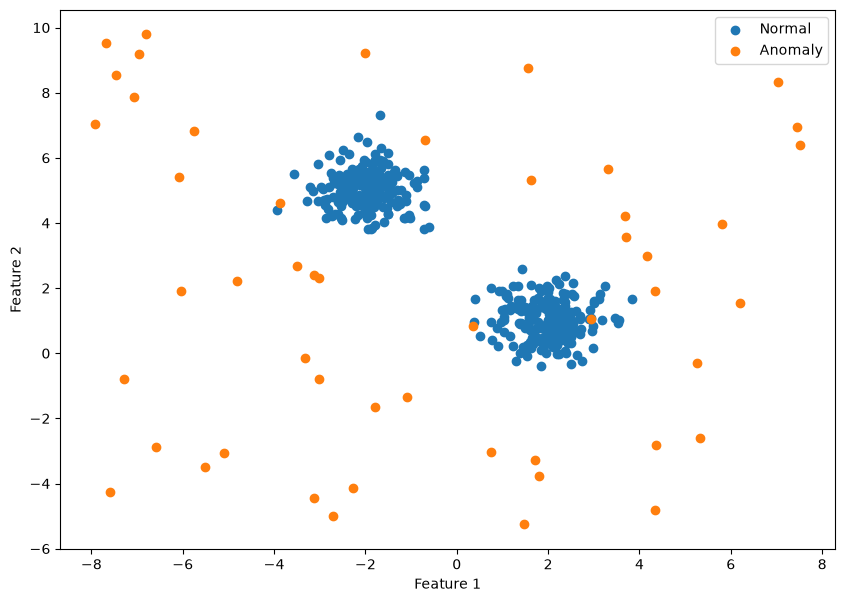

In [4]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_normal[:, 0],
    X_normal[:, 1],
    label="Normal"
)

plt.scatter(
    X_anomalies[:, 0],
    X_anomalies[:, 1],
    label="Anomaly"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [6]:
X

array([[ 2.20309784e+00,  7.50827252e-01],
       [ 1.72996072e+00,  1.37370996e+00],
       [ 1.68636619e+00,  1.62940554e+00],
       [ 2.01699103e+00,  1.01785368e+00],
       [ 1.40623711e+00,  9.24527848e-01],
       [ 1.97741918e+00,  1.66198113e+00],
       [ 3.84732849e+00,  1.67174495e+00],
       [-1.62552811e+00,  5.37700731e+00],
       [-1.87468184e+00,  3.82419793e+00],
       [-2.50807623e+00,  4.09109167e+00],
       [ 2.19938841e+00,  5.50908078e-01],
       [-2.04626103e+00,  5.20469118e+00],
       [ 1.53572648e+00,  2.53207178e-01],
       [-1.78316264e+00,  5.92282194e+00],
       [-1.96386187e+00,  6.47794527e+00],
       [-1.84546977e+00,  4.95533245e+00],
       [ 2.16227410e+00,  9.69857134e-01],
       [-2.06525609e+00,  5.24102703e+00],
       [-2.54481445e+00,  4.15261778e+00],
       [-1.69700763e+00,  5.51945312e+00],
       [-2.48509616e+00,  4.69894577e+00],
       [ 2.15361784e+00,  1.58961459e+00],
       [ 1.61205627e+00,  3.51071198e-01],
       [ 2.

In [12]:
import pandas as pd

df = pd.DataFrame(X)

In [13]:
df

,0,1
0,2.203098,0.750827
1,1.729961,1.373710
2,1.686366,1.629406
3,2.016991,1.017854
4,1.406237,0.924528
...,...,...
445,-6.086492,5.411917
446,4.172561,2.980435
447,4.335475,1.900730
448,0.363725,0.840656


## Isolation Forest Model Implementation

In [14]:
from sklearn.ensemble import IsolationForest

isf = IsolationForest(contamination=0.2)
isf.fit(df)
predictions = isf.predict(df)

In [15]:
predictions

array([ 1,  1,  1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,
        1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1,
        1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,
        1,  1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

In [20]:
index = np.where(predictions < 0)

In [22]:
index

(array([  6,   8,  14,  31,  39,  65,  70,  77,  88,  93, 103, 124, 134,
        138, 153, 160, 171, 179, 184, 192, 201, 209, 211, 247, 273, 276,
        279, 281, 282, 289, 295, 299, 309, 323, 329, 348, 360, 372, 378,
        393, 398, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410,
        411, 412, 413, 414, 415, 416, 417, 418, 420, 421, 422, 423, 424,
        425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437,
        438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 449]),)

In [23]:
X = df.values

### Initial Scatter before applying Isolation Forest

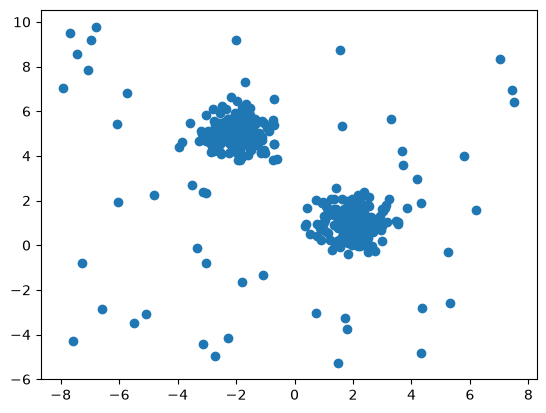

In [26]:
index
plt.scatter(df.iloc[:,0], df.iloc[:,1])

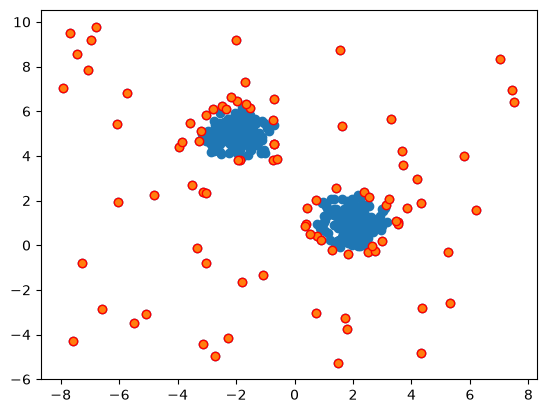

In [28]:
plt.scatter(df.iloc[:,0], df.iloc[:,1])
plt.scatter(X[index,0], X[index,1],edgecolors='r')